<a href="https://colab.research.google.com/github/Shubhambehera29/SENTIMETNT-ANALYSIS/blob/main/sentiment_annalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
# Install required libraries
!pip install -q datasets scikit-learn pandas numpy matplotlib seaborn joblib

In [30]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Libraries imported successfully!")

Libraries imported successfully!


In [31]:
# Download the original IMDb dataset
!wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

# Extract the dataset
!tar -xzf aclImdb_v1.tar.gz

print("IMDb dataset downloaded and extracted successfully!")

IMDb dataset downloaded and extracted successfully!


In [32]:
import os
import pandas as pd

def load_reviews(data_dir):
    reviews = []
    labels = []

    for label_name, label_value in [("pos", 1), ("neg", 0)]:
        folder_path = os.path.join(data_dir, label_name)

        for filename in os.listdir(folder_path):
            if filename.endswith(".txt"):
                file_path = os.path.join(folder_path, filename)

                with open(file_path, "r", encoding="utf-8") as file:
                    review = file.read()

                reviews.append(review)
                labels.append(label_value)

    return pd.DataFrame({
        "text": reviews,
        "label": labels
    })

train_imdb = load_reviews("aclImdb/train")
test_imdb = load_reviews("aclImdb/test")

print("IMDb Training samples:", len(train_imdb))
print("IMDb Testing samples:", len(test_imdb))

display(train_imdb.head())

IMDb Training samples: 25000
IMDb Testing samples: 25000


,text,label
0,I don't think anyone besides Terrence Malick a...,1
1,While the sparkling chemistry between Ryan and...,1
2,"Spoilers Following: I picked up the book ""Evil...",1
3,Michael Curtiz directed this 1930 very-stylish...,1
4,I was especially delighted that in this movie ...,1


In [33]:
# Download Yelp Polarity dataset
yelp_train_raw = load_dataset("fancyzhx/yelp_polarity", split="train")
yelp_test_raw = load_dataset("fancyzhx/yelp_polarity", split="test")

print("Yelp train samples:", len(yelp_train_raw))
print("Yelp test samples:", len(yelp_test_raw))

README.md:   0%|          | 0.00/8.93k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  256MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 17.7MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Yelp train samples: 560000
Yelp test samples: 38000


In [34]:
# Convert Yelp dataset to pandas
yelp_train = yelp_train_raw.to_pandas()
yelp_test = yelp_test_raw.to_pandas()

# Keep only required columns
yelp_train = yelp_train[["text", "label"]]
yelp_test = yelp_test[["text", "label"]]

print(yelp_train.head())
print(yelp_train["label"].value_counts())

                                                text  label
0  Unfortunately, the frustration of being Dr. Go...      0
1  Been going to Dr. Goldberg for over 10 years. ...      1
2  I don't know what Dr. Goldberg was like before...      0
3  I'm writing this review to give you a heads up...      0
4  All the food is great here. But the best thing...      1
label
0    280000
1    280000
Name: count, dtype: int64


In [35]:
# Download Amazon Polarity dataset
amazon_train_raw = load_dataset("fancyzhx/amazon_polarity", split="train")
amazon_test_raw = load_dataset("fancyzhx/amazon_polarity", split="test")

print("Amazon train samples:", len(amazon_train_raw))
print("Amazon test samples:", len(amazon_test_raw))
amazon_train = amazon_train_raw.to_pandas()
amazon_test = amazon_test_raw.to_pandas()

# Amazon dataset contains:
# title, content, label

# Combine title and review content
amazon_train["text"] = (
    amazon_train["title"].fillna("") + " " +
    amazon_train["content"].fillna("")
)

amazon_test["text"] = (
    amazon_test["title"].fillna("") + " " +
    amazon_test["content"].fillna("")
)

amazon_train = amazon_train[["text", "label"]]
amazon_test = amazon_test[["text", "label"]]

print(amazon_train.head())
print(amazon_train["label"].value_counts())

README.md:   0%|          | 0.00/6.81k [00:00<?, ?B/s]

amazon_polarity/train-00000-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  260MB            

amazon_polarity/train-00000-of-00004.par(…): downloading bytes:           |  0.00B            

amazon_polarity/train-00001-of-00004.par(…): reconstructing file:   0%|          |  0.00B /  258MB            

amazon_polarity/train-00001-of-00004.par(…): downloading bytes:           |  0.00B            

...

amazon_polarity/test-00000-of-00001.parq(…): reconstructing file:   0%|          |  0.00B /  117MB            

amazon_polarity/test-00000-of-00001.parq(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Amazon train samples: 3600000
Amazon test samples: 400000
                                                text  label
0  Stuning even for the non-gamer This sound trac...      1
1  The best soundtrack ever to anything. I'm read...      1
2  Amazing! This soundtrack is my favorite music ...      1
3  Excellent Soundtrack I truly like this soundtr...      1
4  Remember, Pull Your Jaw Off The Floor After He...      1
label
1    1800000
0    1800000
Name: count, dtype: int64


In [36]:
# Download Sentiment140 dataset
!wget -q http://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip

# Extract
!unzip -q trainingandtestdata.zip

print("Sentiment140 dataset downloaded and extracted!")

# Sentiment140 column names
sentiment_columns = [
    "target",
    "ids",
    "date",
    "flag",
    "user",
    "text"
]

sent140_train = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    names=sentiment_columns
)

# Keep only positive and negative tweets
sent140_train = sent140_train[sent140_train["target"].isin([0, 4])].copy()

# Convert labels: 0 -> 0, 4 -> 1
sent140_train["label"] = sent140_train["target"].map({
    0: 0,
    4: 1
})

sent140_train = sent140_train[["text", "label"]]

print("Sentiment140 samples:", len(sent140_train))
display(sent140_train.head())

Sentiment140 dataset downloaded and extracted!
Sentiment140 samples: 1600000


,text,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [37]:
def clean_text(text):
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [38]:
# Clean all datasets
for df in [
    train_imdb, test_imdb,
    yelp_train, yelp_test,
    amazon_train, amazon_test,
    sent140_train
]:
    df["text"] = df["text"].apply(clean_text)

print("Text preprocessing completed!")

Text preprocessing completed!


In [39]:
def balanced_sample(df, n_per_class=10000, random_state=42):
    positive = df[df["label"] == 1]
    negative = df[df["label"] == 0]

    n_pos = min(n_per_class, len(positive))
    n_neg = min(n_per_class, len(negative))

    positive_sample = positive.sample(
        n=n_pos,
        random_state=random_state
    )

    negative_sample = negative.sample(
        n=n_neg,
        random_state=random_state
    )

    result = pd.concat(
        [positive_sample, negative_sample],
        ignore_index=True
    )

    return result.sample(
        frac=1,
        random_state=random_state
    ).reset_index(drop=True)

In [40]:
# 10,000 positive + 10,000 negative from each dataset

imdb_sample = balanced_sample(
    train_imdb,
    n_per_class=10000
)

yelp_sample = balanced_sample(
    yelp_train,
    n_per_class=10000
)

amazon_sample = balanced_sample(
    amazon_train,
    n_per_class=10000
)

sent140_sample = balanced_sample(
    sent140_train,
    n_per_class=10000
)

print("IMDb sample:", len(imdb_sample))
print("Yelp sample:", len(yelp_sample))
print("Amazon sample:", len(amazon_sample))
print("Sentiment140 sample:", len(sent140_sample))

IMDb sample: 20000
Yelp sample: 20000
Amazon sample: 20000
Sentiment140 sample: 20000


In [42]:
# Add dataset source information
imdb_sample["dataset"] = "IMDb"
yelp_sample["dataset"] = "Yelp"
amazon_sample["dataset"] = "Amazon"
sent140_sample["dataset"] = "Sentiment140"

# Combine datasets
combined_df = pd.concat(
    [
        imdb_sample,
        yelp_sample,
        amazon_sample,
        sent140_sample
    ],
    ignore_index=True
)

# Shuffle
combined_df = combined_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Total combined samples:", len(combined_df))
display(combined_df.head())

Total combined samples: 80000


,text,label,dataset
0,only good if you sleep next to it the are not ...,0,Amazon
1,looked used this phone cover arrived in packag...,0,Amazon
2,@bartelme yes and that is not acceptable!,0,Sentiment140
3,hmmm ... hsbc business banking site seems to b...,0,Sentiment140
4,too small i made sure that the length was long...,0,Amazon


In [43]:
print("Overall sentiment distribution:")
print(combined_df["label"].value_counts())

print("\nDataset distribution:")
print(combined_df["dataset"].value_counts())

Overall sentiment distribution:
label
0    40000
1    40000
Name: count, dtype: int64

Dataset distribution:
dataset
Amazon          20000
Sentiment140    20000
IMDb            20000
Yelp            20000
Name: count, dtype: int64


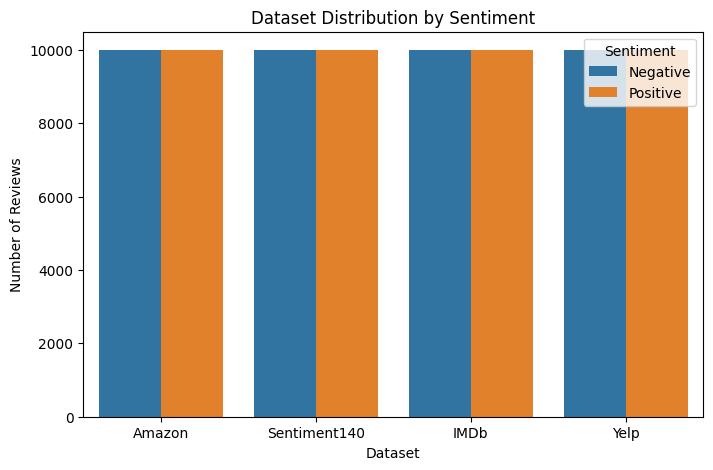

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=combined_df,
    x="dataset",
    hue="label"
)

plt.title("Dataset Distribution by Sentiment")
plt.xlabel("Dataset")
plt.ylabel("Number of Reviews")
plt.legend(title="Sentiment", labels=["Negative", "Positive"])
plt.show()

In [45]:
X = combined_df["text"]
y = combined_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 64000
Testing samples: 16000


In [46]:
# Create TF-IDF + Logistic Regression pipeline

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=100000,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            C=2.0,
            solver="liblinear"
        )
    )
])

print("Training model...")

model.fit(X_train, y_train)

print("Model training completed successfully!")

Training model...
Model training completed successfully!


In [47]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 86.66%


In [48]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report:

              precision    recall  f1-score   support

    Negative       0.87      0.86      0.87      8000
    Positive       0.86      0.87      0.87      8000

    accuracy                           0.87     16000
   macro avg       0.87      0.87      0.87     16000
weighted avg       0.87      0.87      0.87     16000



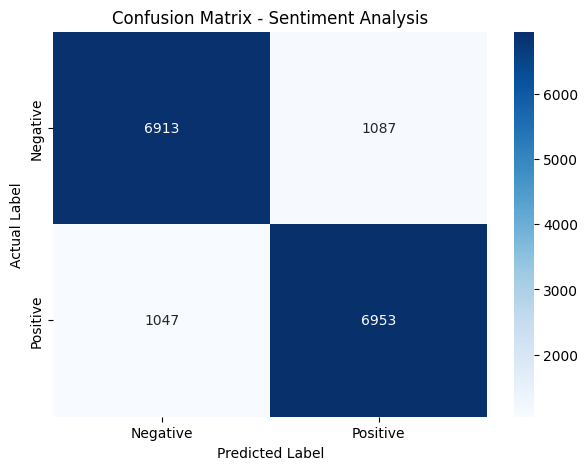

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix - Sentiment Analysis")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [50]:
# Create balanced test samples from each dataset
imdb_test_sample = balanced_sample(
    test_imdb,
    n_per_class=2500
)

yelp_test_sample = balanced_sample(
    yelp_test,
    n_per_class=2500
)

amazon_test_sample = balanced_sample(
    amazon_test,
    n_per_class=2500
)

print("IMDb test:", len(imdb_test_sample))
print("Yelp test:", len(yelp_test_sample))
print("Amazon test:", len(amazon_test_sample))

IMDb test: 5000
Yelp test: 5000
Amazon test: 5000


In [51]:
def evaluate_dataset(model, df, dataset_name):
    predictions = model.predict(df["text"])

    accuracy = accuracy_score(
        df["label"],
        predictions
    )

    print(f"{dataset_name} Accuracy: {accuracy * 100:.2f}%")

    return accuracy

imdb_acc = evaluate_dataset(
    model,
    imdb_test_sample,
    "IMDb"
)

yelp_acc = evaluate_dataset(
    model,
    yelp_test_sample,
    "Yelp"
)

amazon_acc = evaluate_dataset(
    model,
    amazon_test_sample,
    "Amazon"
)

IMDb Accuracy: 88.52%
Yelp Accuracy: 92.42%
Amazon Accuracy: 89.74%


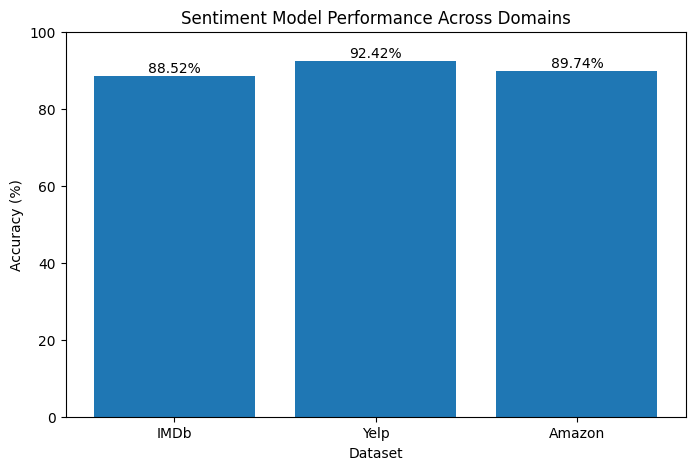

In [52]:
dataset_names = ["IMDb", "Yelp", "Amazon"]
accuracies = [imdb_acc, yelp_acc, amazon_acc]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    dataset_names,
    [acc * 100 for acc in accuracies]
)

plt.title("Sentiment Model Performance Across Domains")
plt.xlabel("Dataset")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc * 100:.2f}%",
        ha="center"
    )

plt.show()

In [53]:
def predict_sentiment(user_text):
    # Clean input text
    cleaned_text = clean_text(user_text)

    # Predict class
    prediction = model.predict([cleaned_text])[0]

    # Predict probability
    probabilities = model.predict_proba([cleaned_text])[0]

    confidence = max(probabilities) * 100

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence

In [54]:
while True:
    user_text = input("Enter a review (or type 'exit' to stop): ")

    if user_text.lower() == "exit":
        print("Prediction session ended.")
        break

    sentiment, confidence = predict_sentiment(user_text)

    print(f"Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.2f}%")
    print()

Enter a review (or type 'exit' to stop): Today i got completlety wet due to rain in my area as i forgot my umbrella
Sentiment: Negative
Confidence: 87.47%

Enter a review (or type 'exit' to stop): the product i receivedis not upto the mark
Sentiment: Negative
Confidence: 92.73%

Enter a review (or type 'exit' to stop): You customer service was on time i appreciate it
Sentiment: Positive
Confidence: 71.94%

Enter a review (or type 'exit' to stop): The product only ran  for 6 months and then is workoing slowly
Sentiment: Negative
Confidence: 70.99%

Enter a review (or type 'exit' to stop): i got scolded by my mother today
Sentiment: Positive
Confidence: 55.67%

Enter a review (or type 'exit' to stop): i got a ps5 tofday
Sentiment: Negative
Confidence: 69.36%

Enter a review (or type 'exit' to stop): i got a burn today
Sentiment: Negative
Confidence: 74.16%

Enter a review (or type 'exit' to stop): i got a mark on the product when i receivedit
Sentiment: Negative
Confidence: 57.57%

Enter

In [55]:
# Save the complete pipeline
joblib.dump(model, "sentiment_analysis_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [56]:
# Load saved model
loaded_model = joblib.load("sentiment_analysis_model.pkl")

# Test loaded model
test_text = "I really enjoyed this product!"

prediction = loaded_model.predict([test_text])[0]
probability = loaded_model.predict_proba([test_text])[0].max()

print("Sentiment:", "Positive" if prediction == 1 else "Negative")
print(f"Confidence: {probability * 100:.2f}%")

Sentiment: Positive
Confidence: 96.81%


In [57]:
# Custom reviews not taken from the datasets

custom_reviews = [
    "The wireless headphones have excellent sound quality and the battery lasts all day.",
    "The package arrived damaged and the product inside was already broken.",
    "The laptop looks premium, runs smoothly, and feels worth the price.",
    "The charging cable stopped working within a week. Very poor quality.",
    "The product is decent, but the instructions could have been clearer.",
    "The food was fresh, flavorful, and the staff were incredibly friendly.",
    "We waited nearly an hour for our food, and it arrived cold.",
    "The restaurant has a lovely atmosphere and the desserts were fantastic.",
    "The portion sizes were disappointing considering how expensive the meal was.",
    "The service was polite, but the food was nothing special.",
    "The story was gripping from beginning to end, and the performances were outstanding.",
    "The plot was predictable, the dialogue felt forced, and the ending was disappointing.",
    "A beautifully made film with excellent cinematography and a memorable soundtrack.",
    "Despite a talented cast, the movie felt slow and lacked emotional depth.",
    "The film had some great moments, but overall it failed to keep me interested.",
    "I expected much more from this product. It looks good, but it barely works.",
    "Not bad at all. The performance is surprisingly impressive.",
    "The design is beautiful, although the battery life is terrible.",
    "I wouldn't recommend this to anyone looking for a reliable device.",
    "The experience exceeded my expectations in every possible way."
]

custom_results = []

for review in custom_reviews:
    sentiment, confidence = predict_sentiment(review)

    custom_results.append({
        "Review": review,
        "Predicted Sentiment": sentiment,
        "Confidence (%)": round(confidence, 2)
    })

custom_results_df = pd.DataFrame(custom_results)

display(custom_results_df)

,Review,Predicted Sentiment,Confidence (%)
0,The wireless headphones have excellent sound q...,Positive,79.68
1,The package arrived damaged and the product in...,Negative,85.80
2,"The laptop looks premium, runs smoothly, and f...",Positive,67.60
3,The charging cable stopped working within a we...,Negative,98.28
4,"The product is decent, but the instructions co...",Negative,92.59
5,"The food was fresh, flavorful, and the staff w...",Positive,83.11
6,"We waited nearly an hour for our food, and it ...",Negative,84.65
7,The restaurant has a lovely atmosphere and the...,Positive,89.37
8,The portion sizes were disappointing consideri...,Negative,90.27
9,"The service was polite, but the food was nothi...",Negative,97.19
